#### Step 1 导入相关包

In [1]:
import pandas as pd
import pickle

import matplotlib.pyplot as plt

#### Step 2 加载数据

In [2]:
# 指定TSV文件路径
file_path = r'E:\tinierZhao_E_recovery\US-AI-Patents-main\US-AI-Patents-main\g_us_patent_citation.tsv\g_us_patent_citation.tsv'  # 替换为你的TSV文件路径

# 读取TSV文件
df = pd.read_csv(file_path, sep='\t')

In [3]:
# 1. 一次性把日期列转成年份，非法日期会变成 NaT
df['citation_year'] = (
    pd.to_datetime(df['citation_date'], errors='coerce')   # 非法变 NaT
      .dt.year                                           # 取年份
      .fillna(1974)                                         # NaT 用 1974 或你指定的兜底年份
      .astype(int)
)

In [5]:
df

,patent_id,citation_sequence,citation_patent_id,citation_date,record_name,wipo_kind,citation_category,citation_year
0,10000000,0,5093563,1992-03-01,Small,A,cited by examiner,1992
1,10000000,1,5751830,1998-05-01,Hutchinson,A,cited by applicant,1998
2,10000001,0,7804268,2010-09-01,Park,B2,cited by examiner,2010
3,10000001,1,9022767,2015-05-01,Oono,B2,cited by examiner,2015
4,10000001,2,9090016,2015-07-01,Takeuchi,B2,cited by examiner,2015
...,...,...,...,...,...,...,...,...
147616685,RE50356,26,9980318,2018-05-01,Uyehara et al.,B2,cited by applicant,2018
147616686,RE50356,27,10164689,2018-12-01,Golubovic,B2,cited by examiner,2018
147616687,RE50356,28,10652955,2020-05-01,Uyehara et al.,B2,cited by applicant,2020
147616688,RE50357,0,8431969,2013-04-01,Kim et al.,B2,cited by applicant,2013


In [6]:
df['patent_id'] = df['patent_id'].astype('str')

In [7]:
# 指定TSV文件路径
patent_file_path = '../g_patent.tsv/g_patent.tsv'  # 替换为你的TSV文件路径

# 读取TSV文件
df_patent_total = pd.read_csv(patent_file_path, sep='\t')

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16940\1948212761.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_patent_total = pd.read_csv(patent_file_path, sep='\t')


In [8]:
df_patent_total

,patent_id,patent_type,patent_date,patent_title,wipo_kind,num_claims,withdrawn,filename
0,10000000,utility,2018-06-19,Coherent LADAR using intra-pixel quadrature de...,B2,20,0,ipg180619.xml
1,10000001,utility,2018-06-19,Injection molding machine and mold thickness c...,B2,12,0,ipg180619.xml
2,10000002,utility,2018-06-19,Method for manufacturing polymer film and co-e...,B2,9,0,ipg180619.xml
3,10000003,utility,2018-06-19,Method for producing a container from a thermo...,B2,18,0,ipg180619.xml
4,10000004,utility,2018-06-19,"Process of obtaining a double-oriented film, c...",B2,6,0,ipg180619.xml
...,...,...,...,...,...,...,...,...
9163780,T998013,defensive publication,1980-09-02,Protection of insect pheromones from degradati...,I4,1,0,pftaps19800902_wk36.zip
9163781,T998014,defensive publication,1980-09-02,"Thiazolyl couplers, coupler compositions and p...",I4,3,0,pftaps19800902_wk36.zip
9163782,T999001,defensive publication,1980-10-07,Sack handling device,I4,1,0,pftaps19801007_wk41.zip
9163783,T999002,defensive publication,1980-10-07,Application of polymeric powders to a substrate,I4,7,0,pftaps19801007_wk41.zip


In [17]:
df_patent_total[df_patent_total['patent_id']==5093563]

,patent_id,patent_type,patent_date,patent_title,wipo_kind,num_claims,withdrawn,filename
3405008,5093563,utility,1992-03-03,Electronically phased detector arrays for opti...,A,72,0,pftaps19920303_wk09.zip


#### Step 3 计算引用时间

In [9]:
file_path = '../../g_application.tsv/g_application.tsv'  # 替换为你的TSV文件路径

# 读取TSV文件
df_application = pd.read_csv(file_path, sep='\t')

# 显示数据框的前几行
df_application.head()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16940\3648069210.py:4: DtypeWarning: Columns (0,2,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_application = pd.read_csv(file_path, sep='\t')


,application_id,patent_id,patent_application_type,filing_date,series_code,rule_47_flag
0,05497504,3963197,05,1074-08-14,05,0.0
1,05508062,3933359,05,1074-09-23,05,0.0
2,05518254,3941467,05,1074-10-29,05,0.0
3,05518570,3936670,05,1074-10-29,05,0.0
4,05555245,4003574,05,1075-03-04,05,0.0


In [10]:
# 1. 一次性把日期列转成年份，非法日期会变成 NaT
df_application['application_year'] = (
    pd.to_datetime(df_application['filing_date'], errors='coerce')   # 非法变 NaT
      .dt.year                                           # 取年份
      .fillna(1974)                                         # NaT 用 1974 或你指定的兜底年份
      .astype(int)
)

In [9]:
df_application[df_application['patent_id']=='10000000']

,application_id,patent_id,patent_application_type,filing_date,series_code,rule_47_flag,application_year
6452310,14643719,10000000,14,2015-03-10,14,0.0,2015


In [10]:
df_application[df_application['patent_id']=='5093563']

,application_id,patent_id,patent_application_type,filing_date,series_code,rule_47_flag,application_year
1124979,7321661,5093563,7,1989-03-03,7,0.0,1989


In [8]:
df_application.head()

,application_id,patent_id,patent_application_type,filing_date,series_code,rule_47_flag,application_year
0,05497504,3963197,05,1074-08-14,05,0.0,1974
1,05508062,3933359,05,1074-09-23,05,0.0,1974
2,05518254,3941467,05,1074-10-29,05,0.0,1974
3,05518570,3936670,05,1074-10-29,05,0.0,1974
4,05555245,4003574,05,1075-03-04,05,0.0,1974


In [21]:
df

,patent_id,citation_sequence,citation_patent_id,citation_date,record_name,wipo_kind,citation_category,citation_year
0,10000000,0,5093563,1992-03-01,Small,A,cited by examiner,1992
1,10000000,1,5751830,1998-05-01,Hutchinson,A,cited by applicant,1998
2,10000001,0,7804268,2010-09-01,Park,B2,cited by examiner,2010
3,10000001,1,9022767,2015-05-01,Oono,B2,cited by examiner,2015
4,10000001,2,9090016,2015-07-01,Takeuchi,B2,cited by examiner,2015
...,...,...,...,...,...,...,...,...
147616685,RE50356,26,9980318,2018-05-01,Uyehara et al.,B2,cited by applicant,2018
147616686,RE50356,27,10164689,2018-12-01,Golubovic,B2,cited by examiner,2018
147616687,RE50356,28,10652955,2020-05-01,Uyehara et al.,B2,cited by applicant,2020
147616688,RE50357,0,8431969,2013-04-01,Kim et al.,B2,cited by applicant,2013


In [11]:
df_patent_total['patent_id'] = df_patent_total['patent_id'].astype('str')

In [12]:
df.head()

,patent_id,citation_sequence,citation_patent_id,citation_date,record_name,wipo_kind,citation_category,citation_year
0,10000000,0,5093563,1992-03-01,Small,A,cited by examiner,1992
1,10000000,1,5751830,1998-05-01,Hutchinson,A,cited by applicant,1998
2,10000001,0,7804268,2010-09-01,Park,B2,cited by examiner,2010
3,10000001,1,9022767,2015-05-01,Oono,B2,cited by examiner,2015
4,10000001,2,9090016,2015-07-01,Takeuchi,B2,cited by examiner,2015


In [13]:
df_cite_with_app_year = (
    df
    .merge(
        df_application[['patent_id', 'application_year']],
        left_on='patent_id',          # 被引专利
        right_on='patent_id',             # df_application 的专利
        how='left'                       
    )
)

In [14]:
df_cite_with_app_year

,patent_id,citation_sequence,citation_patent_id,citation_date,record_name,wipo_kind,citation_category,citation_year,application_year
0,10000000,0,5093563,1992-03-01,Small,A,cited by examiner,1992,2015
1,10000000,1,5751830,1998-05-01,Hutchinson,A,cited by applicant,1998,2015
2,10000001,0,7804268,2010-09-01,Park,B2,cited by examiner,2010,2015
3,10000001,1,9022767,2015-05-01,Oono,B2,cited by examiner,2015,2015
4,10000001,2,9090016,2015-07-01,Takeuchi,B2,cited by examiner,2015,2015
...,...,...,...,...,...,...,...,...,...
147616685,RE50356,26,9980318,2018-05-01,Uyehara et al.,B2,cited by applicant,2018,2022
147616686,RE50356,27,10164689,2018-12-01,Golubovic,B2,cited by examiner,2018,2022
147616687,RE50356,28,10652955,2020-05-01,Uyehara et al.,B2,cited by applicant,2020,2022
147616688,RE50357,0,8431969,2013-04-01,Kim et al.,B2,cited by applicant,2013,2022


In [16]:
df_cite_with_app_year.to_csv('./citations_result/df_cite_with_app_year_1215.csv',index=False)

In [15]:
# 计算年份差值
df_cite_with_app_year['diff_year'] = df_cite_with_app_year['application_year'] - df_cite_with_app_year['citation_year']

In [16]:
df_cite_with_app_year

,patent_id,citation_sequence,citation_patent_id,citation_date,record_name,wipo_kind,citation_category,citation_year,application_year,diff_year
0,10000000,0,5093563,1992-03-01,Small,A,cited by examiner,1992,2015,23
1,10000000,1,5751830,1998-05-01,Hutchinson,A,cited by applicant,1998,2015,17
2,10000001,0,7804268,2010-09-01,Park,B2,cited by examiner,2010,2015,5
3,10000001,1,9022767,2015-05-01,Oono,B2,cited by examiner,2015,2015,0
4,10000001,2,9090016,2015-07-01,Takeuchi,B2,cited by examiner,2015,2015,0
...,...,...,...,...,...,...,...,...,...,...
147616685,RE50356,26,9980318,2018-05-01,Uyehara et al.,B2,cited by applicant,2018,2022,4
147616686,RE50356,27,10164689,2018-12-01,Golubovic,B2,cited by examiner,2018,2022,4
147616687,RE50356,28,10652955,2020-05-01,Uyehara et al.,B2,cited by applicant,2020,2022,2
147616688,RE50357,0,8431969,2013-04-01,Kim et al.,B2,cited by applicant,2013,2022,9


In [17]:
# 5. 统计每个专利在3年和5年内的引用次数
window3 = df_cite_with_app_year[df_cite_with_app_year['diff_year'].between(0, 3)].groupby('citation_patent_id').size().rename('cites_3yr')

In [18]:
# 5. 统计每个专利在3年和5年内的引用次数
window5 = df_cite_with_app_year[df_cite_with_app_year['diff_year'].between(0, 5)].groupby('citation_patent_id').size().rename('cites_5yr')

#### Step 4 计算0~5年被引

In [19]:
# 1. 先把计数结果转成 dict（键 patent_id，值计数）
cites_0_dict = (
    df_cite_with_app_year[df_cite_with_app_year['diff_year'].between(0, 0)]
    .groupby('citation_patent_id')
    .size()
    .to_dict()
)

cites_1_dict = (
    df_cite_with_app_year[df_cite_with_app_year['diff_year'].between(0, 1)]
    .groupby('citation_patent_id')
    .size()
    .to_dict()
)

# 1. 先把计数结果转成 dict（键 patent_id，值计数）
cites_2_dict = (
    df_cite_with_app_year[df_cite_with_app_year['diff_year'].between(0, 2)]
    .groupby('citation_patent_id')
    .size()
    .to_dict()
)

cites_3_dict = (
    df_cite_with_app_year[df_cite_with_app_year['diff_year'].between(0, 3)]
    .groupby('citation_patent_id')
    .size()
    .to_dict()
)

cites_4_dict = (
    df_cite_with_app_year[df_cite_with_app_year['diff_year'].between(0, 4)]
    .groupby('citation_patent_id')
    .size()
    .to_dict()
)

cites_5_dict = (
    df_cite_with_app_year[df_cite_with_app_year['diff_year'].between(0, 5)]
    .groupby('citation_patent_id')
    .size()
    .to_dict()
)

cites_10_dict = (
    df_cite_with_app_year[df_cite_with_app_year['diff_year'].between(0, 10)]
    .groupby('citation_patent_id')
    .size()
    .to_dict()
)

In [20]:
# 2. 用 lambda + dict.get 填 0（缺失或负数都归 0）
df_patent_total['cites_0yr'] = df_patent_total['patent_id'].apply(
    lambda pid: max(cites_0_dict.get(pid, 0), 0)
)

df_patent_total['cites_1yr'] = df_patent_total['patent_id'].apply(
    lambda pid: max(cites_1_dict.get(pid, 0), 0)
)

df_patent_total['cites_2yr'] = df_patent_total['patent_id'].apply(
    lambda pid: max(cites_2_dict.get(pid, 0), 0)
)

df_patent_total['cites_3yr'] = df_patent_total['patent_id'].apply(
    lambda pid: max(cites_3_dict.get(pid, 0), 0)
)

df_patent_total['cites_4yr'] = df_patent_total['patent_id'].apply(
    lambda pid: max(cites_4_dict.get(pid, 0), 0)
)

df_patent_total['cites_5yr'] = df_patent_total['patent_id'].apply(
    lambda pid: max(cites_5_dict.get(pid, 0), 0)
)

df_patent_total['cites_10yr'] = df_patent_total['patent_id'].apply(
    lambda pid: max(cites_10_dict.get(pid, 0), 0)
)

In [21]:
df_patent_total.columns

Index(['patent_id', 'patent_type', 'patent_date', 'patent_title', 'wipo_kind',
       'num_claims', 'withdrawn', 'filename', 'cites_0yr', 'cites_1yr',
       'cites_2yr', 'cites_3yr', 'cites_4yr', 'cites_5yr', 'cites_10yr'],
      dtype='object')

In [23]:
df_patent_total_ = df_patent_total[['patent_id', 'patent_type','cites_0yr', 'cites_1yr','cites_2yr', 'cites_3yr', 'cites_4yr', 'cites_5yr', 'cites_10yr']]

In [24]:
df_patent_total_

,patent_id,patent_type,cites_0yr,cites_1yr,cites_2yr,cites_3yr,cites_4yr,cites_5yr,cites_10yr
0,10000000,utility,4,6,7,9,11,11,12
1,10000001,utility,0,0,0,0,0,0,0
2,10000002,utility,0,0,0,0,0,0,0
3,10000003,utility,1,1,2,2,2,2,2
4,10000004,utility,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...
9163780,T998013,defensive publication,0,0,0,0,0,0,0
9163781,T998014,defensive publication,0,0,0,0,0,0,0
9163782,T999001,defensive publication,0,0,0,0,0,0,0
9163783,T999002,defensive publication,0,0,0,0,0,0,0


In [44]:
df_patent_total_.to_csv('./citations_result/0_5_citations.csv',index=False)

#### Step 4 绘制相关性系数图

In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np

In [62]:
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "axes.labelsize": 20,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15
})

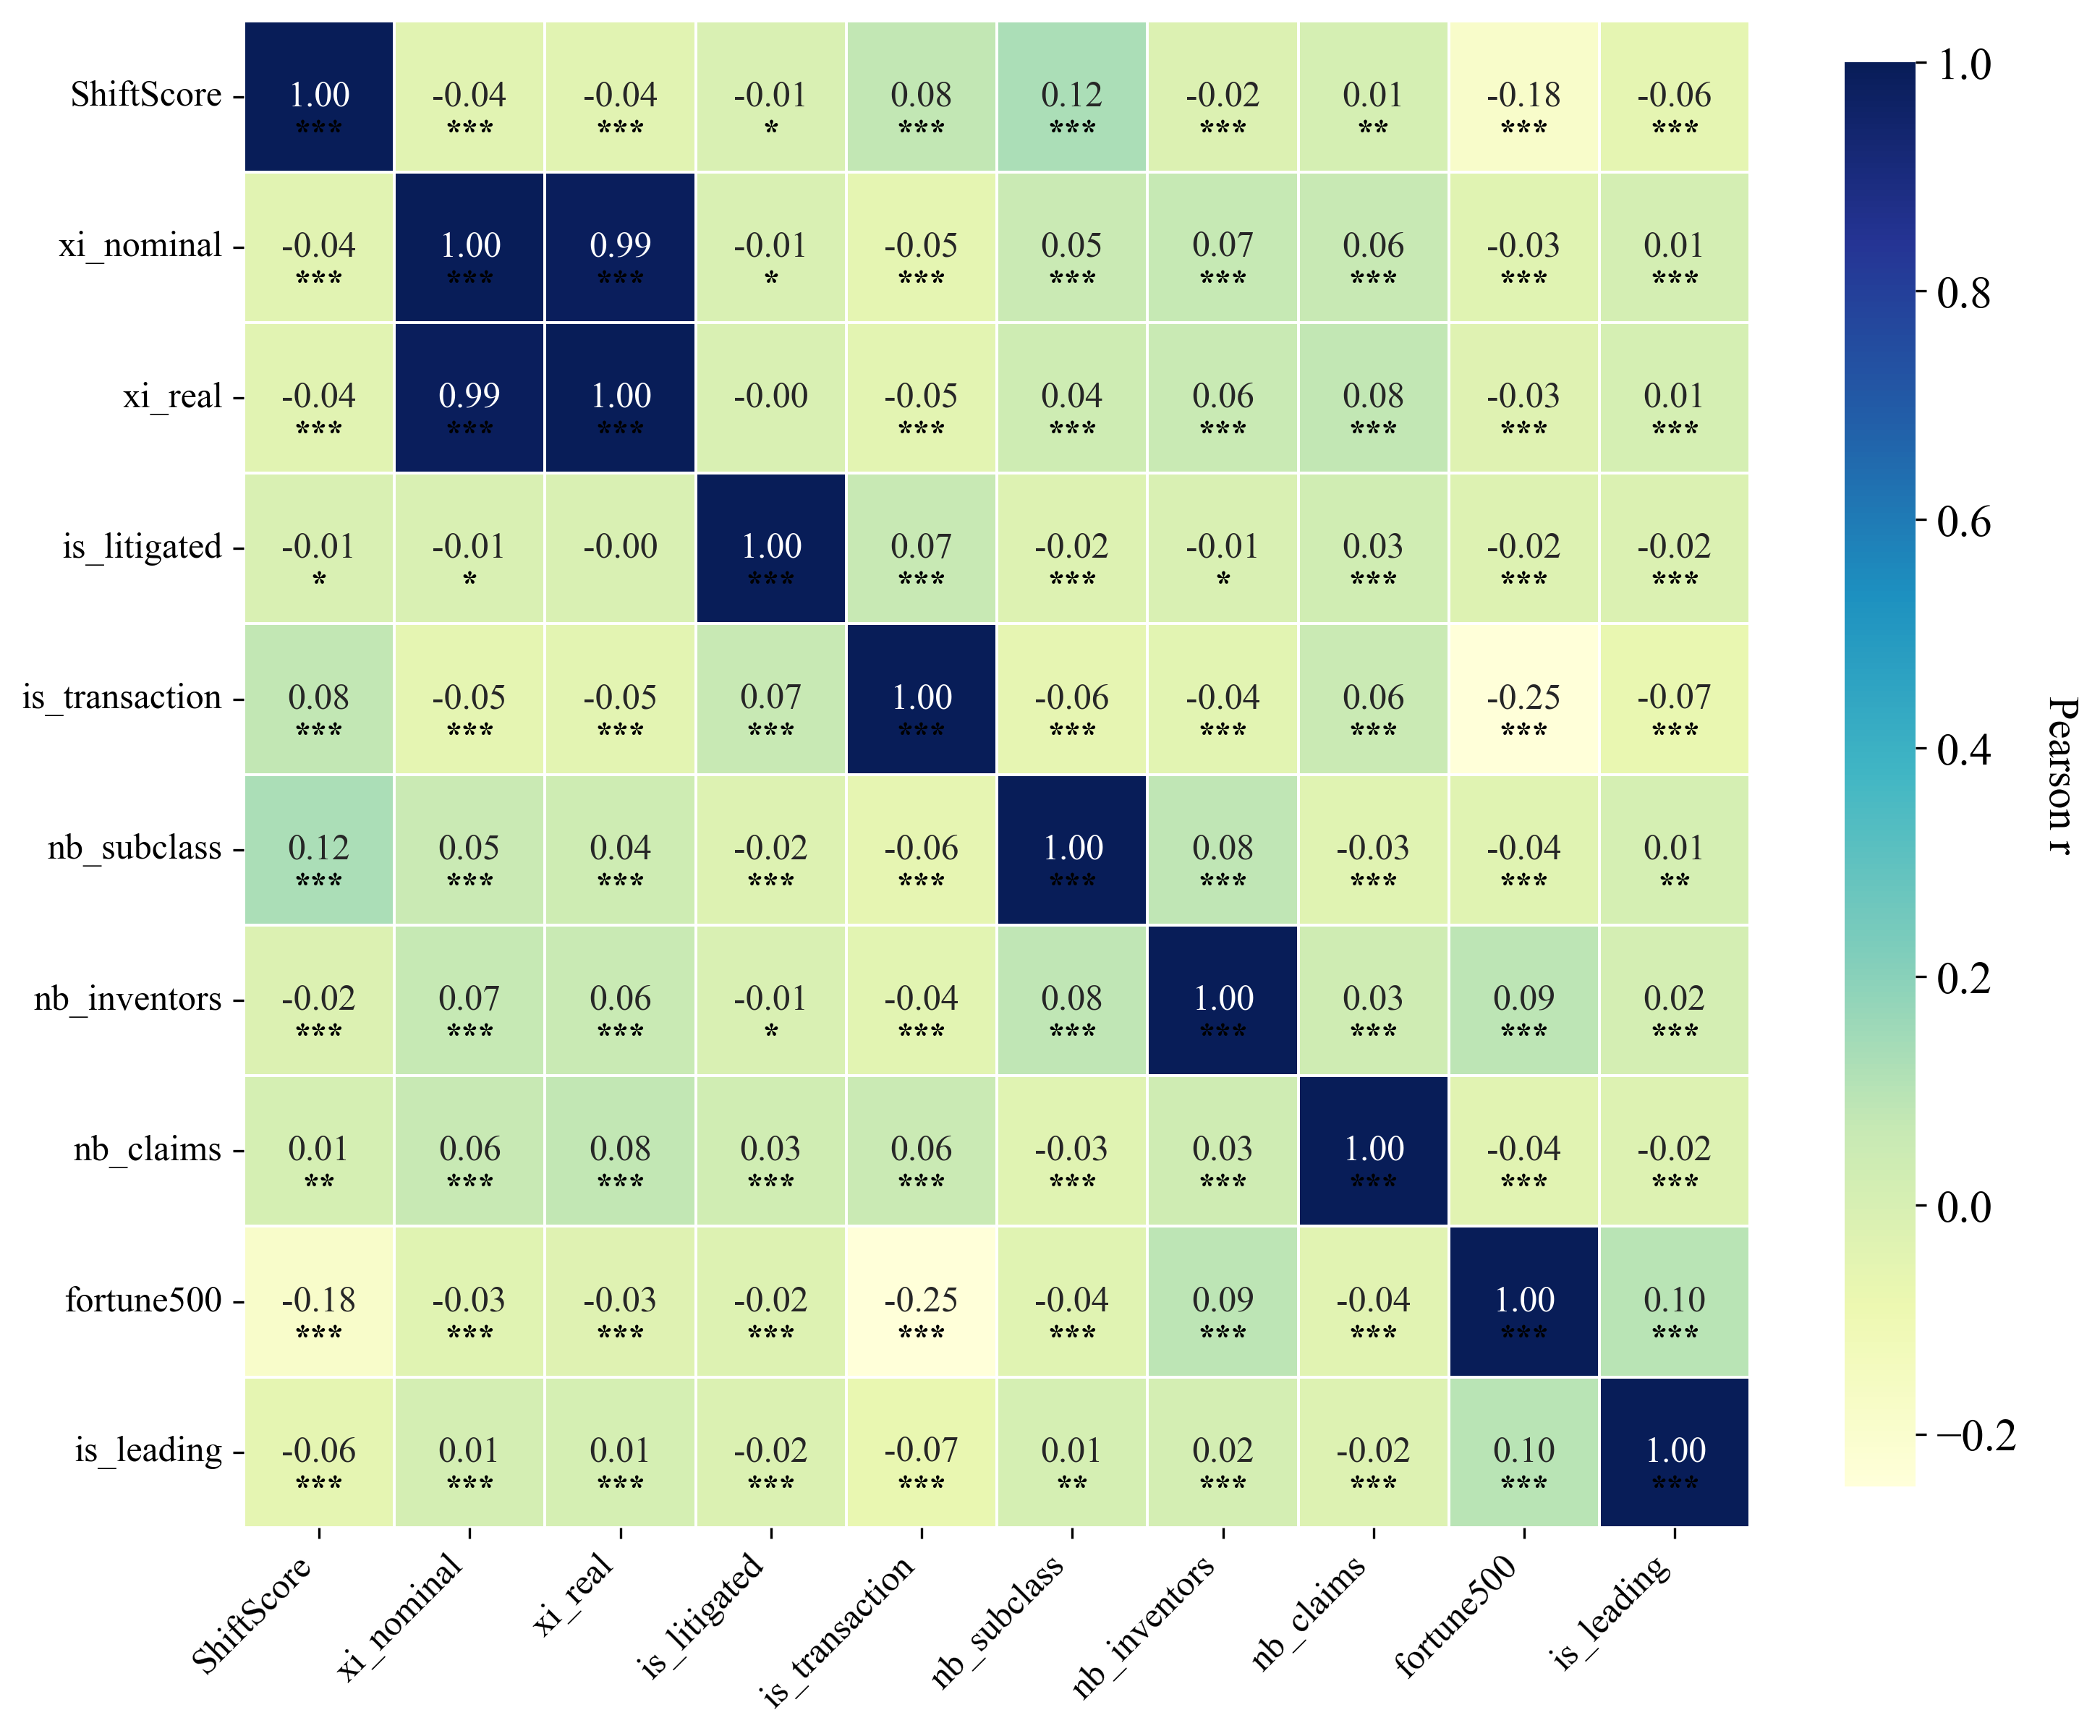

In [90]:
cols = ['avg_difference',
        'xi_nominal',
        'xi_real',
        'is_litigated',
        'is_transaction',
        'ipc_class_count',
        'inventor_count',
        'num_claims',
        'is_fortune_500',
        'ai_stronge']

# 2. 删除缺失值
df_clean = df_econmics[cols].dropna()

# -------------------------------------------------
# 3. 计算相关性与 p 值
corr = df_clean.corr(method='pearson')
p_mat = np.full_like(corr, np.nan)

for i, c1 in enumerate(cols):
    for j, c2 in enumerate(cols):
        p_mat[i, j] = pearsonr(df_clean[c1], df_clean[c2])[1]

# 4. 星号标记
def p2star(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

star_mat = np.vectorize(p2star)(p_mat)

# -------------------------------------------------
# 5. 绘图
plt.figure(figsize=(10, 9), dpi=300)

# 自定义坐标名（简洁版）
labels = ['ShiftScore', 'xi_nominal', 'xi_real',
          'is_litigated', 'is_transaction', 'nb_subclass',
          'nb_inventors', 'nb_claims', 'fortune500', 'is_leading']

ax = sns.heatmap(corr,
                 annot=True,
                 fmt='.2f',
                 cmap='YlGnBu',
                 square=True,
                 linewidths=.5,
                 cbar_kws={'shrink': .8},
                 annot_kws={'size': 12},
                 xticklabels=labels,
                 yticklabels=labels,
                 )

# 在格子里追加星号
for i in range(len(labels)):
    for j in range(len(labels)):
        star = star_mat[i, j]
        if star:  # 只画显著的星号
            ax.text(j + 0.5, i + 0.75, star,
                    ha='center', va='center', color='black', fontsize=11, weight='bold')

# 色条标签
cbar = ax.collections[0].colorbar
cbar.set_label('Pearson r', rotation=270, labelpad=20, size=14)

# 轴标签旋转
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)

plt.tight_layout()
plt.show()

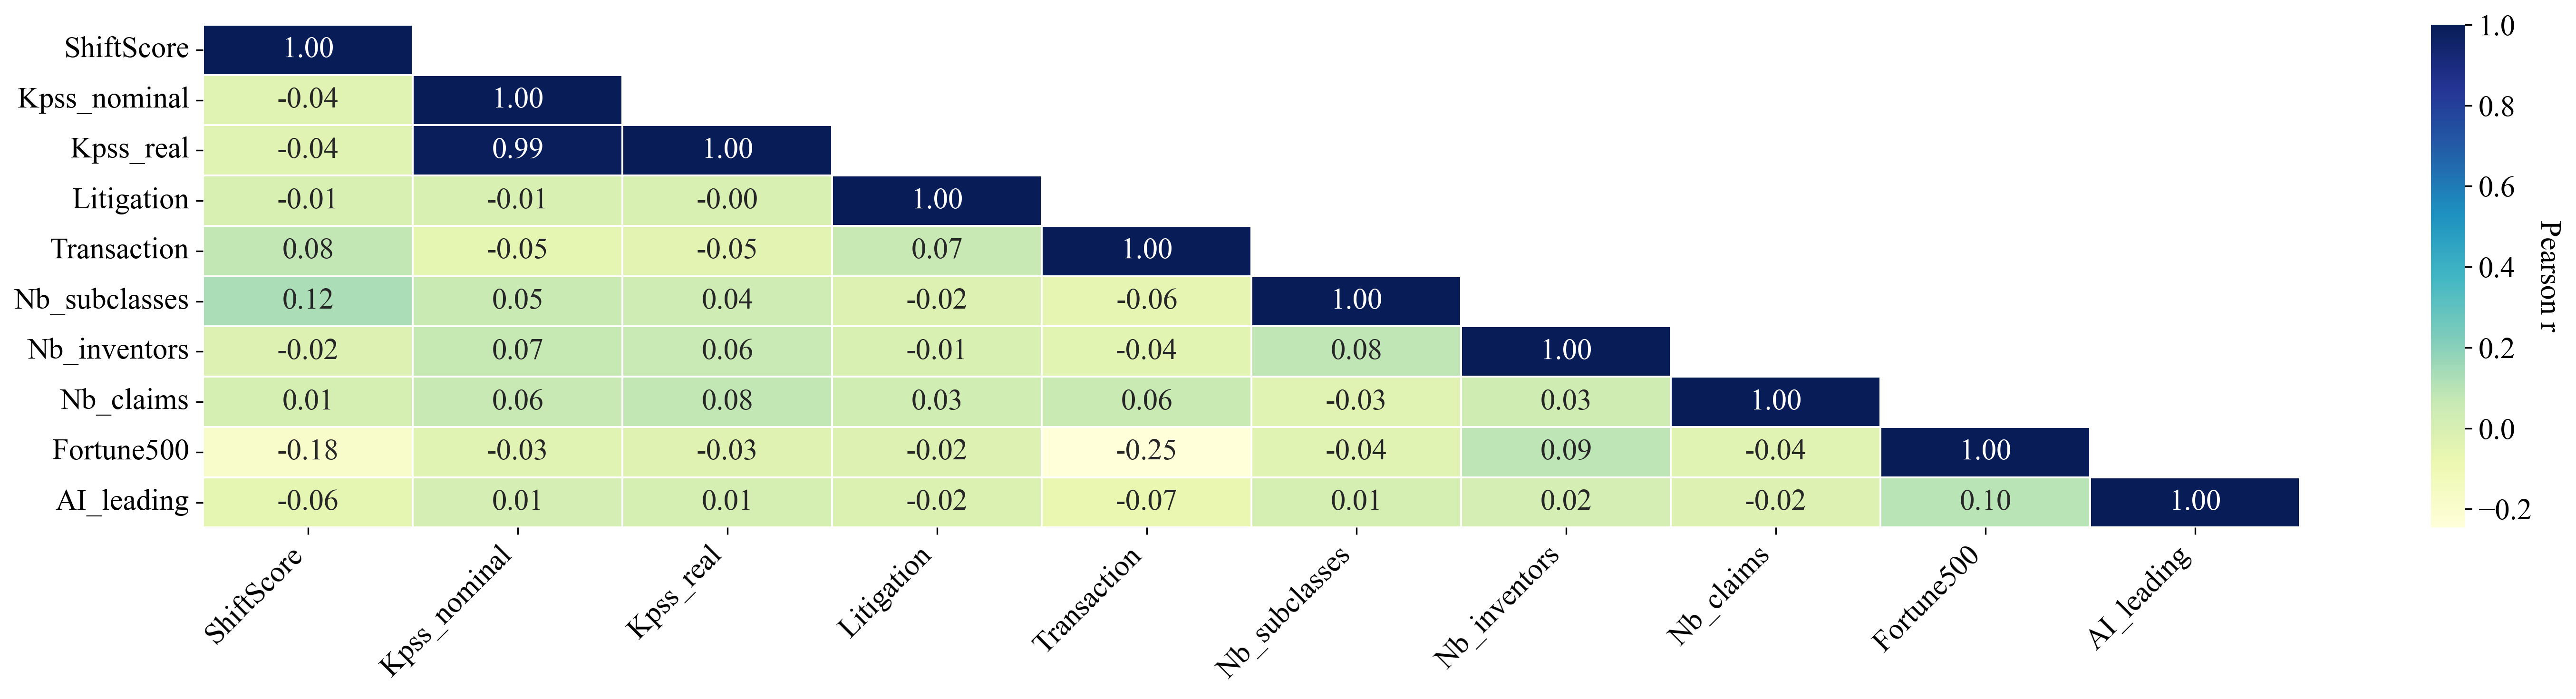

In [134]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ---------- 5. 瘦长、下三角热图 ----------
plt.figure(figsize=(20, 5), dpi=300)

labels = ['ShiftScore', 'Kpss_nominal', 'Kpss_real',
          'Litigation', 'Transaction', 'Nb_subclasses',
          'Nb_inventors', 'Nb_claims', 'Fortune500', 'AI_leading']

# 遮住上三角（含对角线）
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

ax = sns.heatmap(corr,
                 mask=mask,
                 annot=True,
                 fmt='.2f',
                 cmap='YlGnBu',
                 square=False,
                 linewidths=.5,
                 cbar_kws={'shrink': 1, 'aspect': 15},
                 annot_kws={'size': 15},
                 xticklabels=labels,
                 yticklabels=labels)

# 星号（同样只画下三角）
for i in range(len(labels)):
    for j in range(i):          # 只遍历下三角
        star = star_mat[i, j]
        if not star:
            ax.text(j + 0.5, i + 0.9, star,
                    ha='center', va='center',
                    color='black', fontsize=10, weight='bold')

cbar = ax.collections[0].colorbar
cbar.set_label('Pearson r', rotation=270, labelpad=15, size=15)

plt.xticks(rotation=45, ha='right', fontsize=15)
plt.yticks(rotation=0, fontsize=15)
plt.tight_layout()
plt.show()

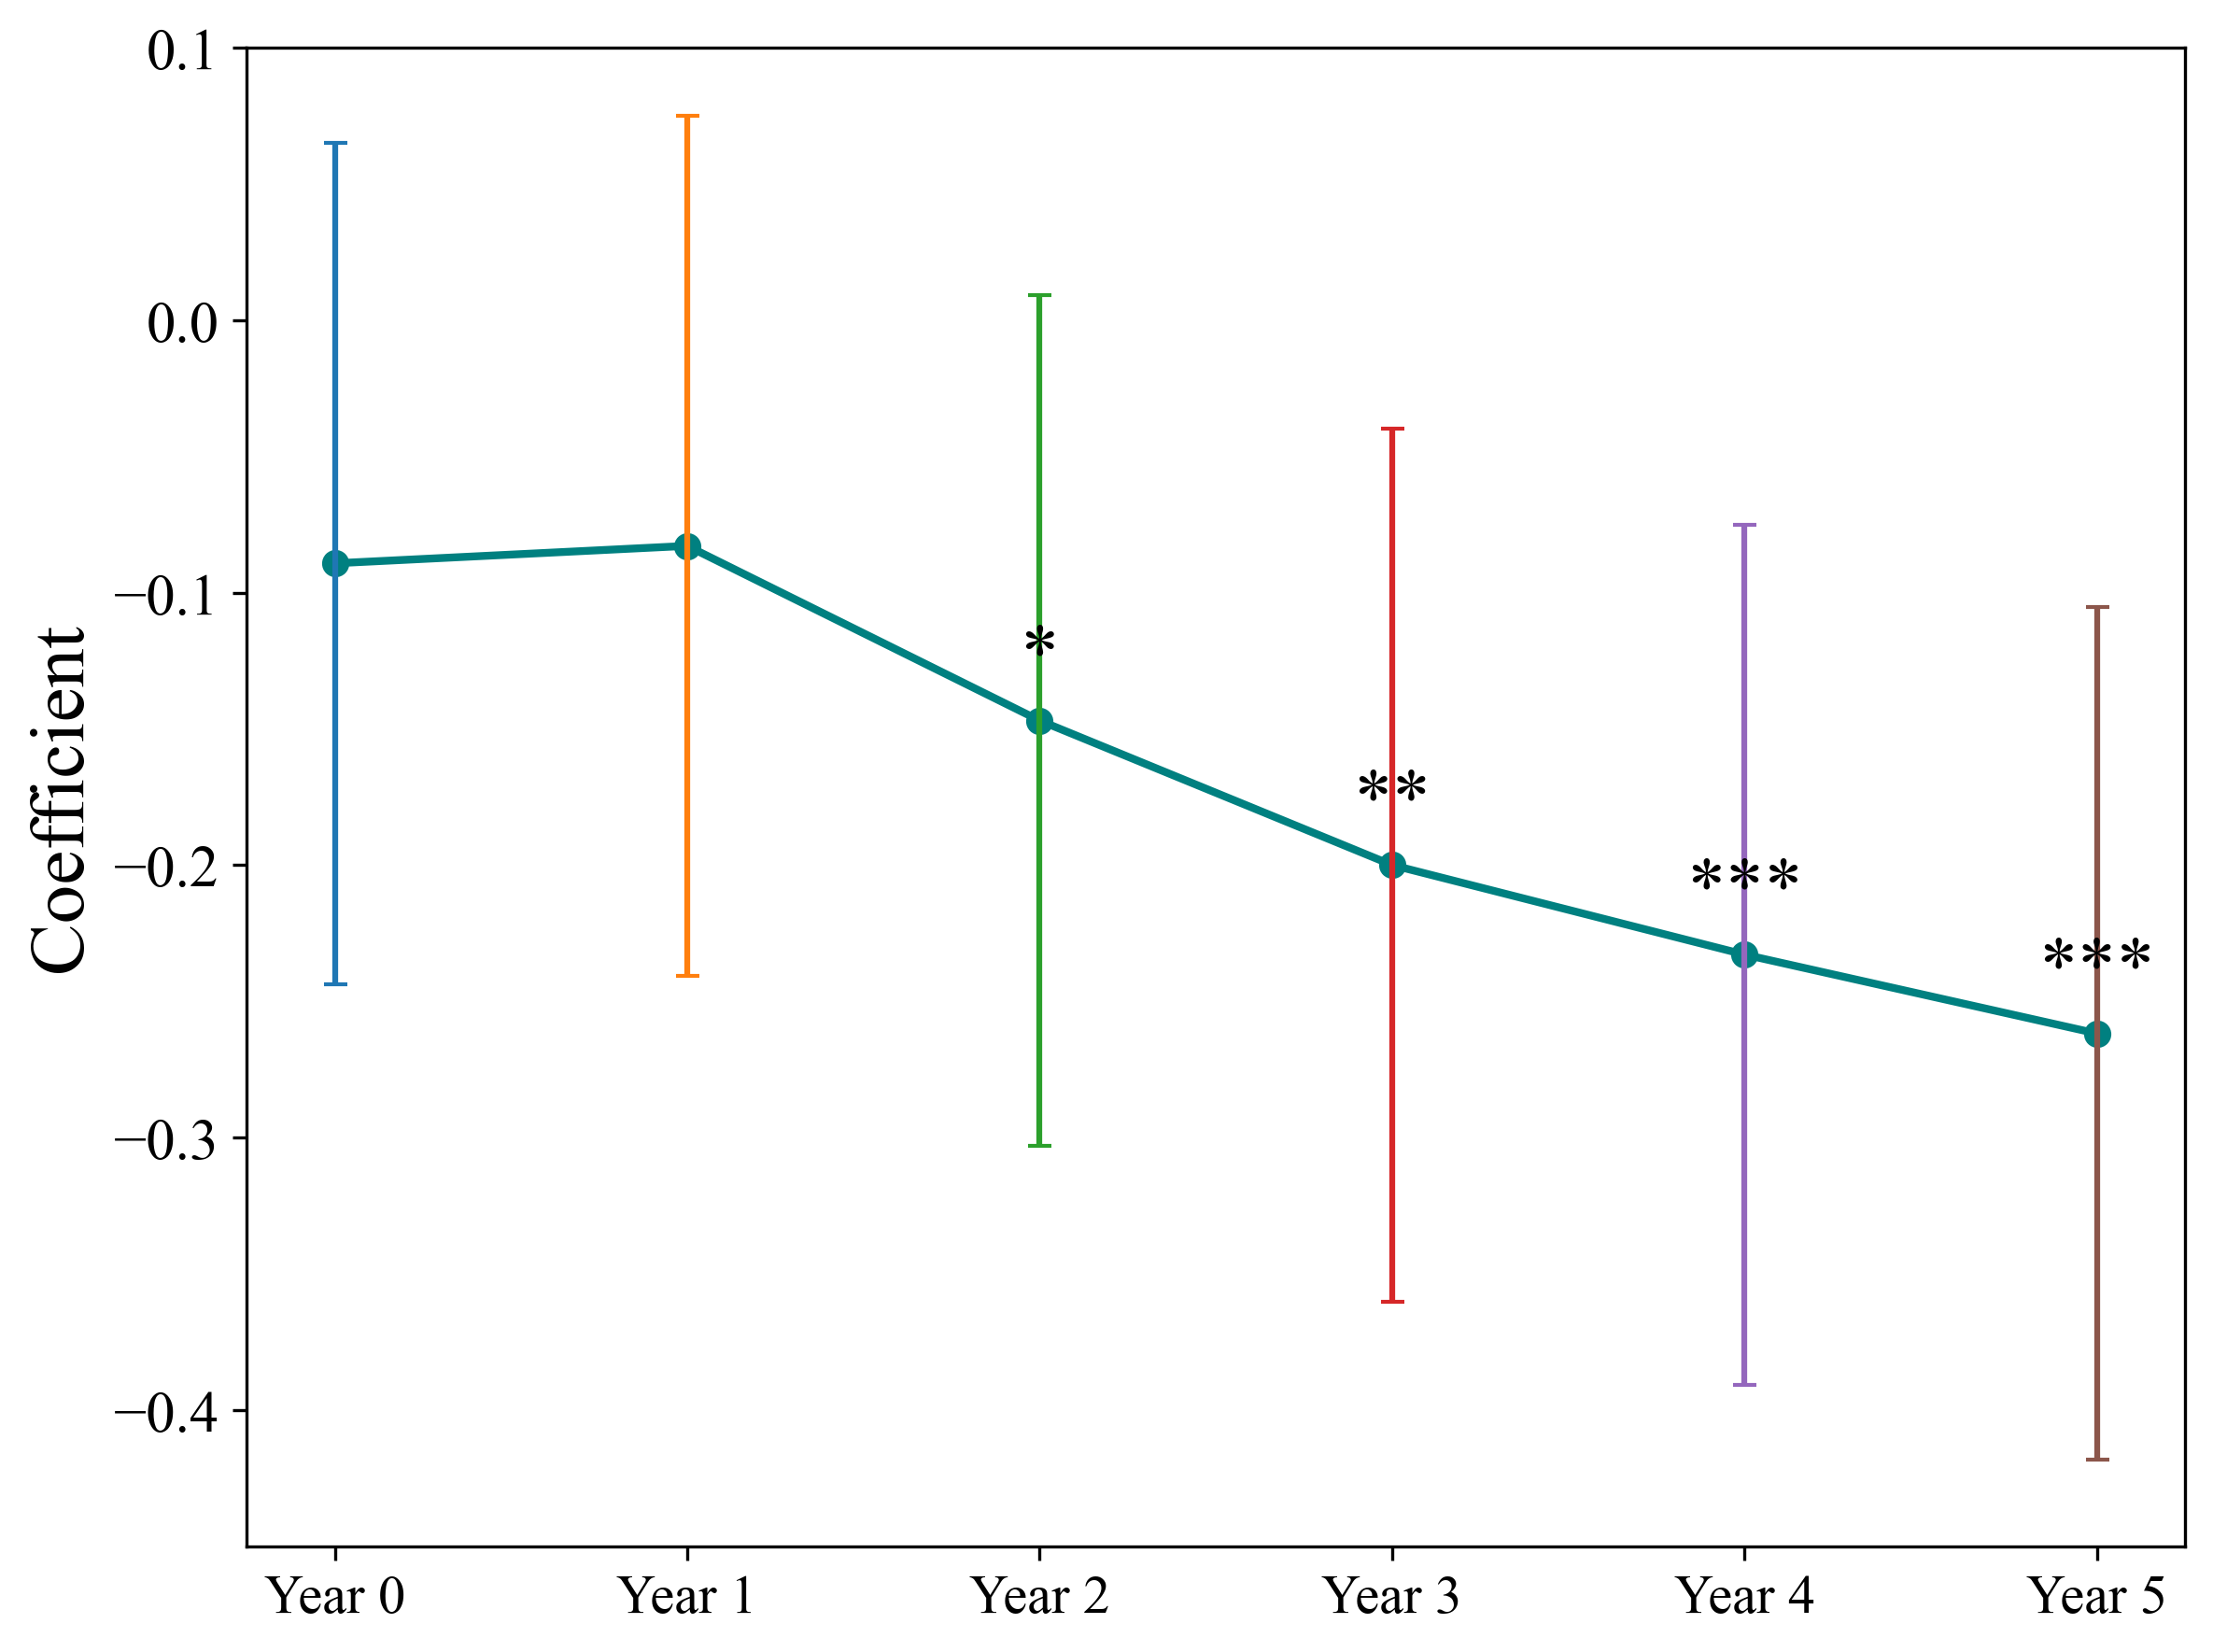

In [85]:
import matplotlib.pyplot as plt
import numpy as np

# 数据准备
x = np.arange(1, 7)  # 保持原x轴位置（1-6）
x_labels = ["Year 0", "Year 1", "Year 2", "Year 3", "Year 4", "Year 5"]  # 年份标签
means = [(lb + ub) / 2 for lb, ub in [
    (-0.2436393, 0.0651457),
    (-0.2408261, 0.075124),
    (-0.3029269, 0.0090449),
    (-0.3602576, -0.0396738),
    (-0.3906548, -0.0750109),
    (-0.4182507, -0.1053388)
]]
# 修正误差格式：每个误差转为[[下误差], [上误差]]，匹配单个y值的维度
errors = [
    [[mean - lb], [ub - mean]] for mean, (lb, ub) in zip(means, [
        (-0.2436393, 0.0651457),
        (-0.2408261, 0.075124),
        (-0.3029269, 0.0090449),
        (-0.3602576, -0.0396738),
        (-0.3906548, -0.0750109),
        (-0.4182507, -0.1053388)
    ])
]
means = np.array(means)

# 显著性标记
significance_marks = ["", "", "*", "**", "***", "***"]
# 误差线颜色（6个年份对应6种颜色，保持区分度）
error_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# 绘图
plt.figure(figsize=(8, 6), dpi=300)

# 绘制主折线
plt.plot(x, means, 'o-', color='teal', linewidth=2)

# 逐个年份绘制误差线（修正后yerr格式）
for i in range(6):
    plt.errorbar(
        x[i], means[i], 
        yerr=errors[i],  # 已调整为[[下误差], [上误差]]格式
        fmt='none',
        ecolor=error_colors[i],
        capsize=3, 
        elinewidth=1.5
    )

# 添加显著性标记
for i in range(6):
    xi = x[i]
    mark = significance_marks[i]
    y_pos = means[i] + 0.01
    plt.text(xi, y_pos, mark, ha='center', va='bottom', color='black', fontsize=20)

# 坐标轴设置
plt.xticks(x, x_labels, fontsize=14)
plt.ylabel('Coefficient', fontsize=20)
plt.ylim(-0.45, 0.1)
plt.tight_layout()
plt.show()

ValueError: 'yerr' (shape: (2,)) must be a scalar or a 1D or (2, n) array-like whose shape matches 'y' (shape: (1,))

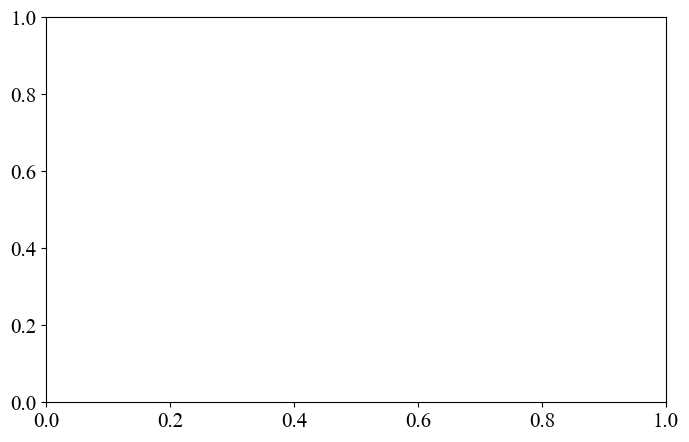

In [80]:
import matplotlib.pyplot as plt
import numpy as np

# 自定义颜色（视觉区分度好的科学配色）
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']  

# 数据准备（年份从0到5）
x = np.arange(6)  # x坐标：0,1,2,3,4,5
x_labels = ["Year 0", "Year 1", "Year 2", "Year 3", "Year 4", "Year 5"]

# 置信区间数据
confidence_intervals = [
    (-0.2436393, 0.0651457),
    (-0.2408261, 0.075124),
    (-0.3029269, 0.0090449),
    (-0.3602576, -0.0396738),
    (-0.3906548, -0.0750109),
    (-0.4182507, -0.1053388)
]

# 计算均值（用于折线点）和误差（上下限与均值的差值）
means = [(lb + ub) / 2 for lb, ub in confidence_intervals]
errors = [(mean - lb, ub - mean) for mean, (lb, ub) in zip(means, confidence_intervals)]

# 显著性标记
significance_marks = ["", "", "*", "**", "***", "***"]

# 绘图
plt.figure(figsize=(8, 5))

# 逐个绘制年份数据（核心修正：yerr格式）
for i in range(len(x)):
    # 关键修正：单个点的yerr需要是“(下误差, 上误差)”的元组，或长度为2的列表
    plt.errorbar(
        x=x[i],  # 单个年份x坐标
        y=means[i],  # 单个年份的均值
        yerr=errors[i],  # 用(下误差, 上误差)元组，适配单个点的y
        fmt='o-',  # 圆点标记+实线连接
        color=colors[i],  # 每年颜色不同
        ecolor=colors[i],  # 误差线与点同色
        capsize=3,  # 误差线端点横线长度
        linewidth=1.5  # 连接线粗细（可选）
    )

# 添加显著性标记
for i in range(len(x)):
    # 计算标记位置（避免超出置信区间）
    upper_bound = confidence_intervals[i][1]  # 原始置信区间上限
    y_pos = means[i] + 0.01 if (means[i] + 0.01) < upper_bound else upper_bound - 0.01
    plt.text(
        x=x[i],
        y=y_pos,
        s=significance_marks[i],
        ha='center',  # 水平居中
        va='bottom',  # 垂直对齐底部
        color='black',
        fontsize=12
    )

# 图形标注与样式
plt.xticks(x, x_labels)  # 横轴标签为Year 0到Year 5
plt.ylabel('Coefficient', fontsize=12)  # 纵轴标签（系数）
plt.title('Trend of Coefficients with Confidence Intervals', fontsize=14, pad=20)
plt.ylim(-0.5, 0.1)  # 固定y轴范围（根据数据调整，更直观）
plt.grid(linestyle='--', alpha=0.5)  # 添加网格线（可选，便于读数）
plt.tight_layout()  # 自动调整布局，避免标签重叠

plt.show()